# EDA - Polymarket Price Data

This notebook explores raw Polymarket price series and the processed feature set produced by the scripts.
Outputs are saved under `data/processed/eda`.

Scope:
- Data coverage, missing days, and duplicates
- Price and return distributions
- Volatility regimes and outlier days
- Rolling stats and autocorrelation (no extra deps)
- Feature and label EDA from processed dataset

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RAW_DIR = ROOT / "data" / "raw"
PROC_DIR = ROOT / "data" / "processed"
OUT_DIR = PROC_DIR / "eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [3]:
from src.features import build_market_features, build_labels

def load_price_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "date" not in df.columns or "price" not in df.columns:
        return pd.DataFrame()
    df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce").dt.normalize()
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df = df.dropna(subset=["date", "price"]).copy()
    if "slug" not in df.columns or df["slug"].isna().all():
        df["slug"] = path.stem.replace("prices_", "")
    return df

def compute_coverage(prices_all: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for slug, g in prices_all.groupby("slug"):
        g = g.sort_values("date")
        min_date = g["date"].min()
        max_date = g["date"].max()
        n_rows = len(g)
        n_unique = g["date"].nunique()
        if pd.isna(min_date) or pd.isna(max_date):
            expected = 0
        else:
            expected = (max_date - min_date).days + 1
        missing = max(expected - n_unique, 0)
        dup = max(n_rows - n_unique, 0)
        rows.append({
            "slug": slug,
            "start_date": min_date,
            "end_date": max_date,
            "n_rows": n_rows,
            "n_unique_dates": n_unique,
            "span_days": expected,
            "missing_days": missing,
            "dup_days": dup,
            "price_min": float(g["price"].min()),
            "price_max": float(g["price"].max()),
            "price_mean": float(g["price"].mean()),
            "price_std": float(g["price"].std(ddof=0)),
        })
    return pd.DataFrame(rows)

def add_log_returns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.sort_values(["slug", "date"]).copy()
    out["log_price"] = np.log(out["price"] + 1e-8)
    out["ret_1d"] = out.groupby("slug")["log_price"].diff()
    return out

## Load raw data and processed features

We start by verifying that the raw price CSVs and the catalog/summary tables load cleanly, alongside the processed feature file if it exists. The outputs show the files are found and the tables render, so downstream joins between raw series and features are safe.

In [4]:
catalog_path = RAW_DIR / "markets_catalog.csv"
summary_path = RAW_DIR / "collection_summary.csv"
features_path = PROC_DIR / "features_all.csv"

catalog = pd.read_csv(catalog_path) if catalog_path.exists() else pd.DataFrame()
collection_summary = pd.read_csv(summary_path) if summary_path.exists() else pd.DataFrame()

price_files = sorted(RAW_DIR.glob("prices_*.csv"))
price_parts = [load_price_file(p) for p in price_files]
price_parts = [p for p in price_parts if not p.empty]
prices_all = pd.concat(price_parts, ignore_index=True) if price_parts else pd.DataFrame()

print(f"Price files: {len(price_files)}")
print(f"Rows loaded: {len(prices_all)}")
print(f"Markets: {prices_all['slug'].nunique() if not prices_all.empty else 0}")

display(catalog.head(3))
display(collection_summary.head(3))
prices_all.head()

Price files: 500
Rows loaded: 30559
Markets: 500


,slug,question,outcomes,volume,startDate,endDate,clobTokenIds
0,us-recession-in-2025,US recession in 2025?,"[""Yes"", ""No""]",1.173451e+07,2025-01-08T01:33:54.924Z,2026-02-28T12:00:00Z,['10417355721474453757042434534720954458577584...
1,will-gta-6-cost-100,Will GTA 6 cost $100+?,"[""Yes"", ""No""]",8.069449e+06,2025-03-06T20:51:01.626726Z,2026-02-28T12:00:00Z,['28946595841244317705636126646676849578876740...
2,will-the-us-collect-between-500b-and-1t-in-rev...,Will the U.S. collect between $500b and $1t in...,"[""Yes"", ""No""]",2.670721e+06,2025-04-15T22:24:07.509458Z,2026-02-28T12:00:00Z,['14642427631762357507939608294887050551300827...


,slug,question,n_prices,n_articles
0,us-recession-in-2025,US recession in 2025?,358,38
1,will-gta-6-cost-100,Will GTA 6 cost $100+?,360,0
2,will-the-us-collect-between-500b-and-1t-in-rev...,Will the U.S. collect between $500b and $1t in...,320,0


,date,price,slug,question
0,2023-12-29 00:00:00+00:00,0.235,2023-24-detroit-pistons-worst-nba-team-of-all-...,2023-24 Detroit Pistons worst NBA team of all ...
1,2023-12-30 00:00:00+00:00,0.200,2023-24-detroit-pistons-worst-nba-team-of-all-...,2023-24 Detroit Pistons worst NBA team of all ...
2,2023-12-31 00:00:00+00:00,0.160,2023-24-detroit-pistons-worst-nba-team-of-all-...,2023-24 Detroit Pistons worst NBA team of all ...
3,2024-01-01 00:00:00+00:00,0.125,2023-24-detroit-pistons-worst-nba-team-of-all-...,2023-24 Detroit Pistons worst NBA team of all ...
4,2024-01-02 00:00:00+00:00,0.115,2023-24-detroit-pistons-worst-nba-team-of-all-...,2023-24 Detroit Pistons worst NBA team of all ...


## Coverage, missing days, duplicates

Here we check date coverage, missing days, duplicates, and price ranges per market. Most markets have full daily coverage with no duplicates, and only a few have small gaps (for example, will-trump-win-the-2024-iowa-caucus has 6 missing days, will-the-us-collect-less-than-100b-in-revenue-in-2025 has 4, and bitboy-convicted has 2). The longest series span about 360-370 days, and prices cover near-0 to near-1 ranges, suggesting many markets sit at extremes for long stretches.

In [5]:
coverage = compute_coverage(prices_all)

if not catalog.empty and "slug" in catalog.columns and "volume" in catalog.columns:
    coverage = coverage.merge(catalog[["slug", "volume"]], on="slug", how="left")

coverage = coverage.sort_values("n_rows", ascending=False).reset_index(drop=True)
coverage.to_csv(OUT_DIR / "market_coverage.csv", index=False)
coverage.head(10)

,slug,start_date,end_date,n_rows,n_unique_dates,span_days,missing_days,dup_days,price_min,price_max,price_mean,price_std,volume
0,bitboy-convicted,2025-03-27 00:00:00+00:00,2026-04-01 00:00:00+00:00,369,369,371,2,0,0.0255,0.7900,0.425660,0.162423,8.366216e+05
1,will-gta-6-cost-100,2025-03-07 00:00:00+00:00,2026-03-01 00:00:00+00:00,360,360,360,0,0,0.0005,0.1665,0.064251,0.041871,8.069449e+06
2,us-recession-in-2025,2025-01-09 00:00:00+00:00,2026-01-01 00:00:00+00:00,358,358,358,0,0,0.0015,0.6550,0.213895,0.169147,1.173451e+07
3,will-trump-elon-reduce-the-deficit-in-2025,2025-02-01 00:00:00+00:00,2026-01-14 00:00:00+00:00,348,348,348,0,0,0.0025,0.3700,0.164320,0.065993,2.389988e+05
4,will-the-us-collect-between-200b-and-500b-in-r...,2025-04-16 00:00:00+00:00,2026-03-01 00:00:00+00:00,320,320,320,0,0,0.0035,0.8750,0.380902,0.227442,1.116195e+06
5,will-the-us-collect-between-500b-and-1t-in-rev...,2025-04-16 00:00:00+00:00,2026-03-01 00:00:00+00:00,320,320,320,0,0,0.0005,0.2000,0.015533,0.018459,2.670721e+06
6,will-tariffs-generate-250b-in-2025,2025-04-16 00:00:00+00:00,2026-03-01 00:00:00+00:00,320,320,320,0,0,0.0035,0.3300,0.088980,0.070576,1.412916e+06
7,will-the-us-collect-less-than-100b-in-revenue-...,2025-04-16 00:00:00+00:00,2026-02-28 00:00:00+00:00,315,315,319,4,0,0.0020,0.9940,0.177619,0.257969,2.306902e+06
8,will-trump-win-the-2024-iowa-caucus,2023-03-16 00:00:00+00:00,2024-01-16 00:00:00+00:00,301,301,307,6,0,0.3100,0.9875,0.738146,0.138920,9.433203e+04
9,haaland-to-break-pl-goal-record-this-season,2023-08-12 00:00:00+00:00,2024-05-19 00:00:00+00:00,282,282,282,0,0,0.0130,0.5600,0.272457,0.177196,5.449266e+03


In [6]:
missing_rows = []
for slug, g in prices_all.groupby("slug"):
    g = g.sort_values("date")
    min_date = g["date"].min()
    max_date = g["date"].max()
    if pd.isna(min_date) or pd.isna(max_date):
        continue
    expected = pd.date_range(min_date, max_date, freq="D", tz="UTC")
    actual = pd.DatetimeIndex(g["date"].unique())
    missing = expected.difference(actual)
    sample = ";".join([d.strftime("%Y-%m-%d") for d in missing[:10]])
    missing_rows.append({
        "slug": slug,
        "missing_days": int(len(missing)),
        "missing_sample": sample,
    })

missing_df = pd.DataFrame(missing_rows).sort_values("missing_days", ascending=False)
missing_df.to_csv(OUT_DIR / "missing_days.csv", index=False)
missing_df.head(10)

,slug,missing_days,missing_sample
470,will-trump-win-the-2024-iowa-caucus,6,2023-03-22;2023-04-06;2023-04-07;2023-04-29;20...
453,will-the-us-collect-less-than-100b-in-revenue-...,4,2026-02-11;2026-02-16;2026-02-18;2026-02-19
17,bitboy-convicted,2,2026-03-16;2026-03-19
484,will-vivek-ramaswamy-win-the-new-hampshire-rep...,0,
483,will-vivek-ramaswamy-win-the-2024-republican-i...,0,
2,aleo-airdrop-by-april,0,
469,will-trump-tweet-again-by-april-1,0,
471,will-tyson-fury-beat-oleksandr-usyk-in-ring-of...,0,
472,will-ukraine-receive-f-16s-by-end-of-january,0,
473,will-uniswap-fee-switch-proposal-pass,0,


## Price series

We plot representative market paths to see how prices evolve over time. The panels show a mix of steady drifts toward 0, sustained high probabilities, and late surges toward 1, which is consistent with event-driven updates and end-of-market resolution effects.

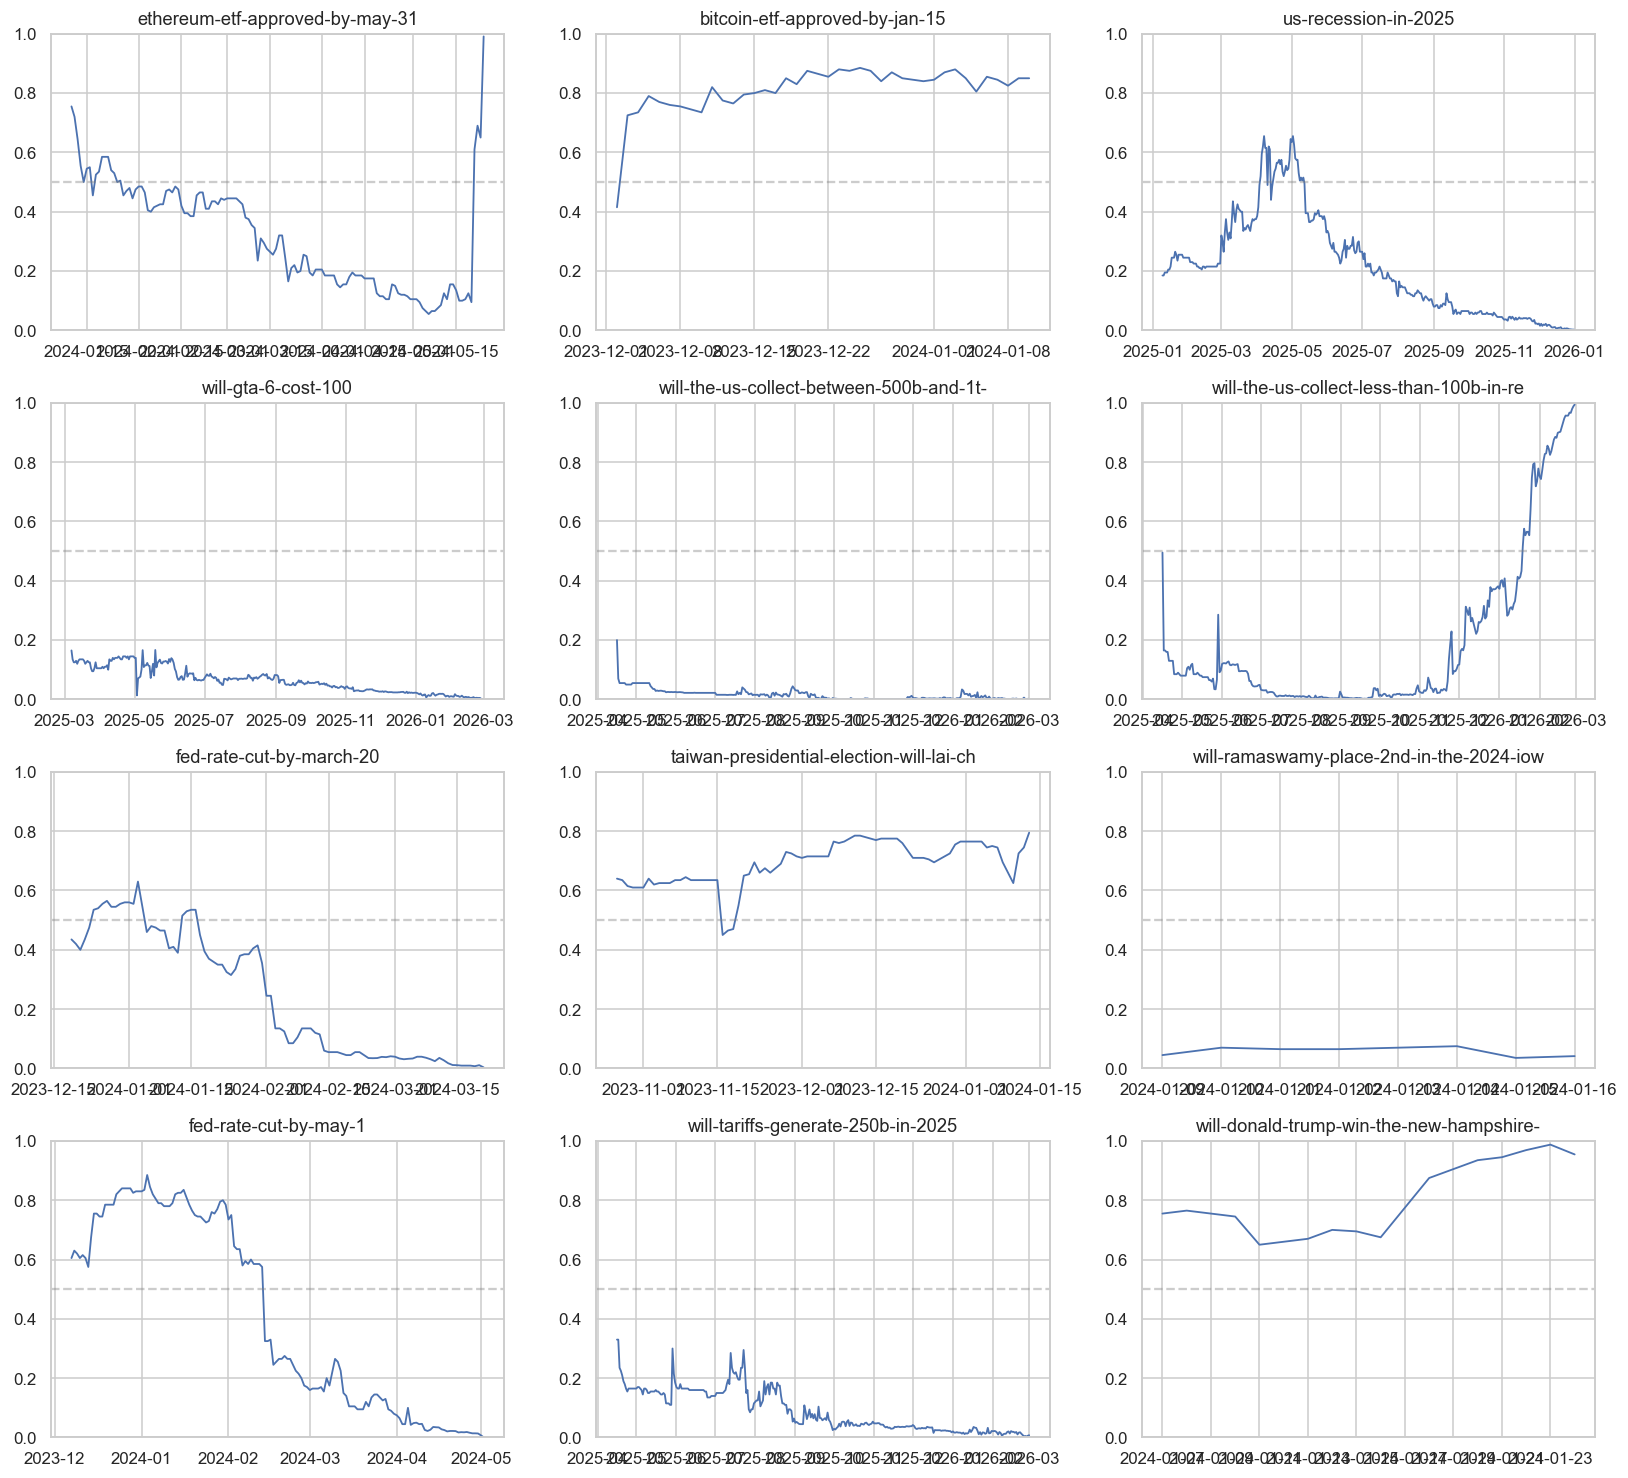

In [7]:
TOP_N = 12
if "volume" in coverage.columns:
    top_slugs = coverage.sort_values("volume", ascending=False)["slug"].head(TOP_N).tolist()
else:
    top_slugs = coverage.sort_values("span_days", ascending=False)["slug"].head(TOP_N).tolist()

plot_df = prices_all[prices_all["slug"].isin(top_slugs)].copy()

cols = 3
rows = int(np.ceil(len(top_slugs) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(15, 3.4 * rows), squeeze=False)
axes_flat = axes.flatten()

for i, slug in enumerate(top_slugs):
    ax = axes_flat[i]
    g = plot_df[plot_df["slug"] == slug].sort_values("date")
    x = g["date"].dt.tz_localize(None)
    ax.plot(x, g["price"], linewidth=1.2)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4)
    ax.set_title(slug[:40])
    ax.set_ylim(0, 1)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
out_path = OUT_DIR / "price_series_top.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()

## Price distribution

We look at the global distribution of prices across all markets and dates. The histogram is concentrated near 0 with a secondary mass around 0.5 and a thinner tail toward 1, meaning many markets spend time at low implied odds while fewer sit at high conviction.

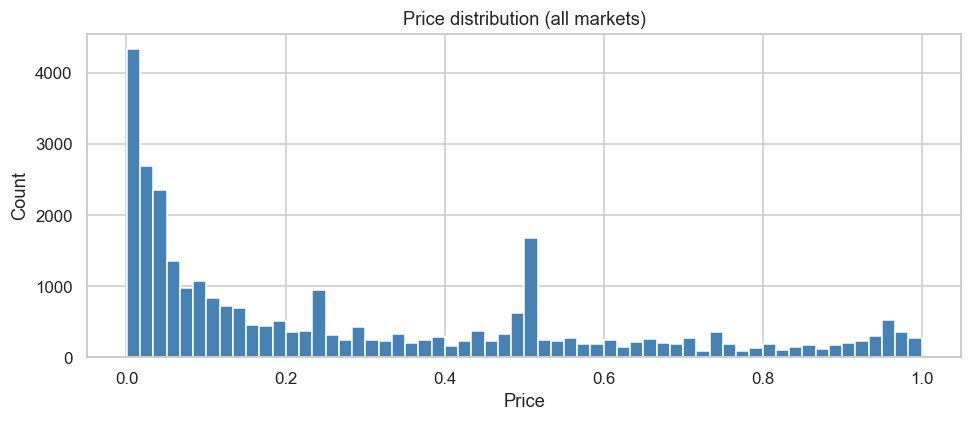

count    30559.000000
mean         0.286735
std          0.294563
min          0.000500
25%          0.036000
50%          0.160000
75%          0.500000
max          0.999500
Name: price, dtype: float64

In [8]:
plt.figure(figsize=(9, 4))
prices_all["price"].hist(bins=60, color="steelblue", edgecolor="white")
plt.title("Price distribution (all markets)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUT_DIR / "price_distribution.png", bbox_inches="tight")
plt.show()

prices_all["price"].describe()

## Returns

We examine daily log return distributions overall and by market. Returns are tightly centered around 0 with heavy tails, indicating many flat days punctuated by sharp jumps, and the per-market curves show asymmetric tails in some cases, consistent with discrete information shocks.

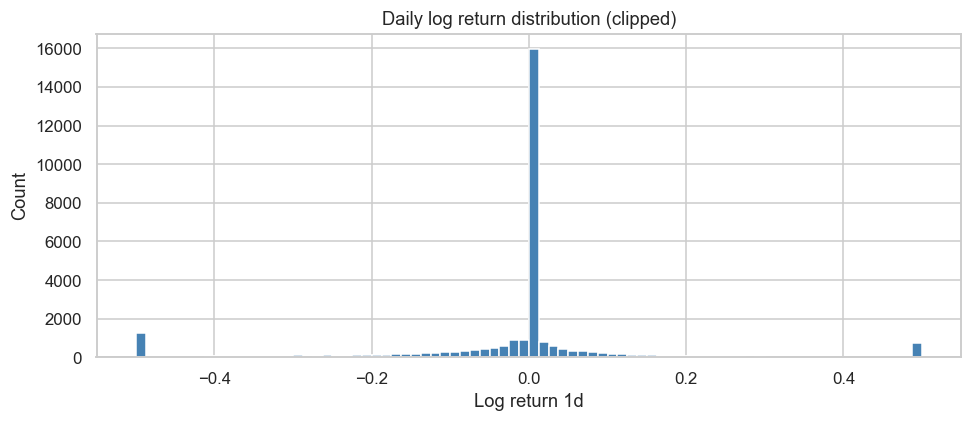

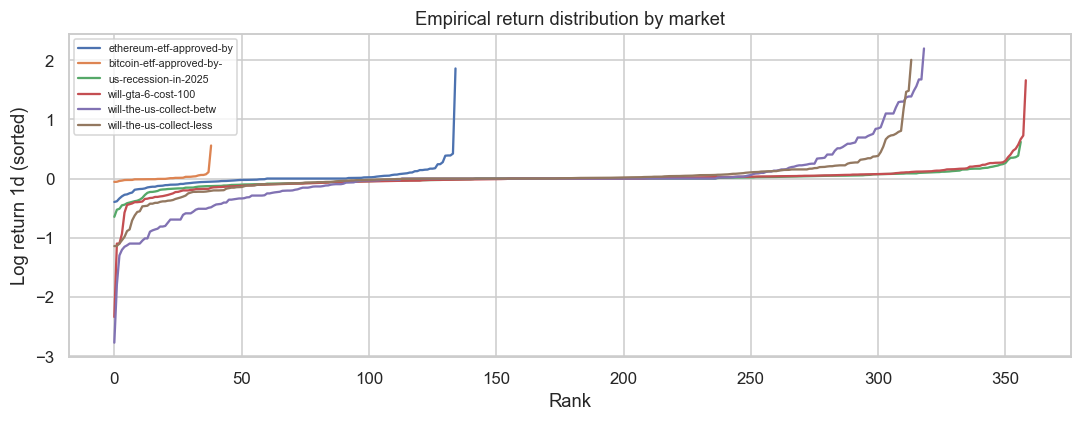

In [9]:
prices_ret = add_log_returns(prices_all)
returns = prices_ret.dropna(subset=["ret_1d"]).copy()

plt.figure(figsize=(9, 4))
returns["ret_1d"].clip(-0.5, 0.5).hist(bins=80, color="steelblue", edgecolor="white")
plt.title("Daily log return distribution (clipped)")
plt.xlabel("Log return 1d")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUT_DIR / "return_distribution.png", bbox_inches="tight")
plt.show()

# Empirical return distributions for a subset
top_for_returns = top_slugs[:6]
plt.figure(figsize=(10, 4))
for slug in top_for_returns:
    s = returns[returns["slug"] == slug]["ret_1d"].dropna().values
    if len(s) == 0:
        continue
    plt.plot(np.sort(s), label=slug[:24])
plt.title("Empirical return distribution by market")
plt.xlabel("Rank")
plt.ylabel("Log return 1d (sorted)")
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig(OUT_DIR / "return_empirical.png", bbox_inches="tight")
plt.show()

## Volatility regimes

We compute rolling volatility and bucket it into regimes. The counts are roughly balanced across low, mid, and high (about 9.6k each) with a small warm-up NA segment, and the rolling plots show clear shifts over time, including volatility cooling after early spikes in some markets and late-stage surges around key events in others.

In [10]:
prices_ret = prices_ret.sort_values(["slug", "date"]).copy()
prices_ret["vol7"] = prices_ret.groupby("slug")["ret_1d"].rolling(7, min_periods=3).std().reset_index(level=0, drop=True)
prices_ret["vol30"] = prices_ret.groupby("slug")["ret_1d"].rolling(30, min_periods=10).std().reset_index(level=0, drop=True)

q_low, q_high = prices_ret["vol7"].quantile([0.33, 0.66]).values
def label_regime(v):
    if pd.isna(v):
        return "na"
    if v <= q_low:
        return "low"
    if v <= q_high:
        return "mid"
    return "high"

prices_ret["vol_regime"] = prices_ret["vol7"].apply(label_regime)
regime_counts = prices_ret["vol_regime"].value_counts(dropna=False).reset_index()
regime_counts.columns = ["regime", "count"]
regime_counts.to_csv(OUT_DIR / "volatility_regimes.csv", index=False)
regime_counts

,regime,count
0,high,9891
1,mid,9600
2,low,9600
3,na,1468


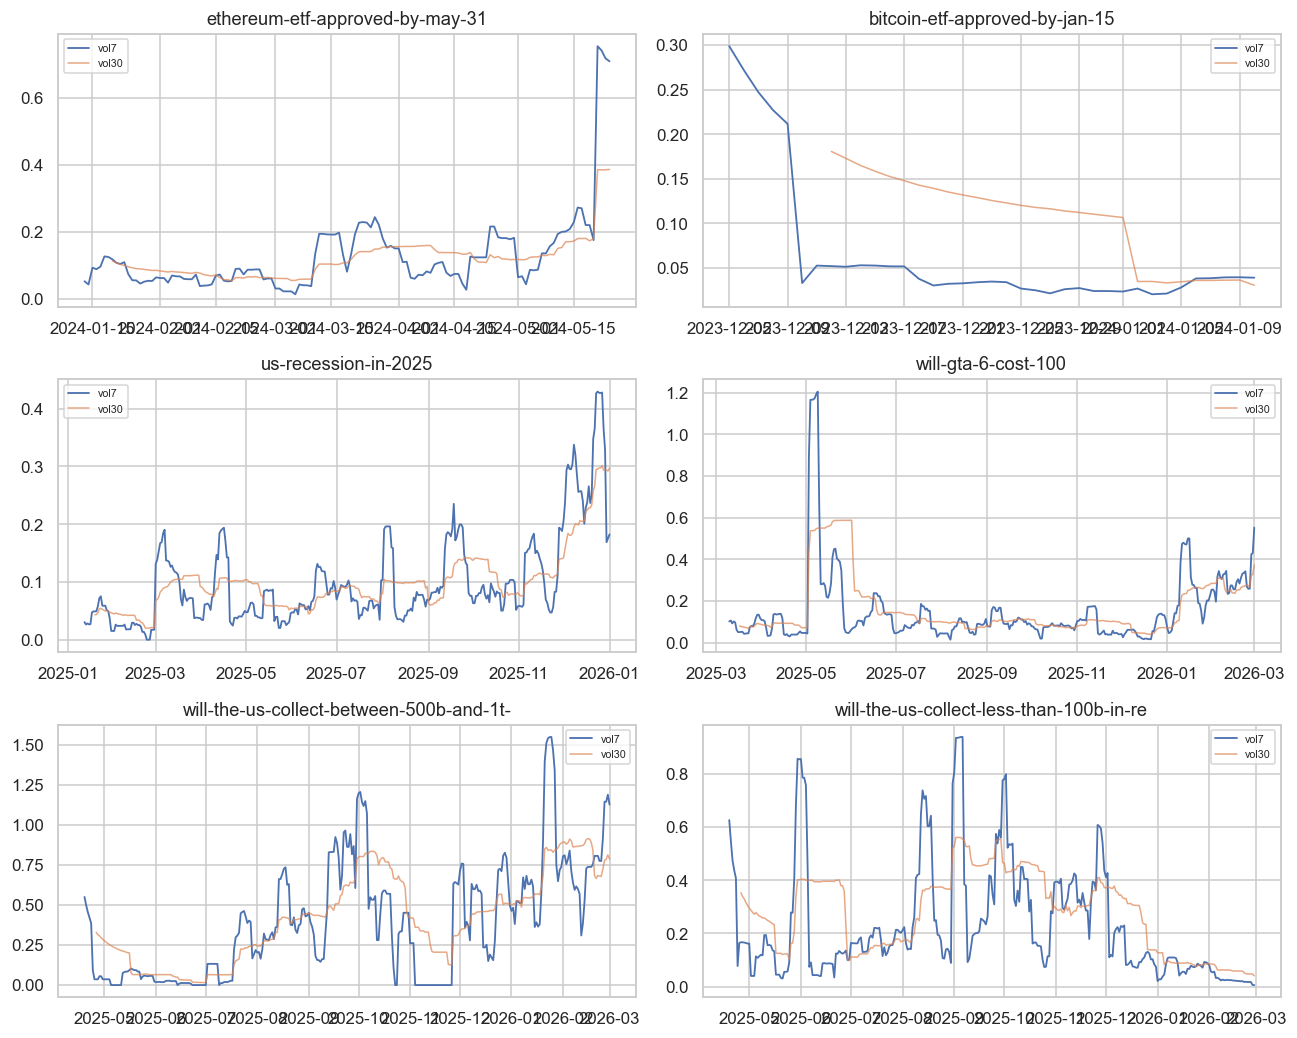

In [11]:
sample_slugs = top_slugs[:6]
cols = 2
rows = int(np.ceil(len(sample_slugs) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(12, 3.2 * rows), squeeze=False)
axes_flat = axes.flatten()

for i, slug in enumerate(sample_slugs):
    ax = axes_flat[i]
    g = prices_ret[prices_ret["slug"] == slug].sort_values("date")
    x = g["date"].dt.tz_localize(None)
    ax.plot(x, g["vol7"], label="vol7", linewidth=1.2)
    ax.plot(x, g["vol30"], label="vol30", linewidth=1.0, alpha=0.7)
    ax.set_title(slug[:40])
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / "rolling_volatility.png", bbox_inches="tight")
plt.show()

## Outlier returns

We flag extreme daily moves using z-scored returns. The outliers cluster in event-heavy markets (airdrop and major political questions), with both sharp drops and jumps, which fits a news-shock interpretation.

In [13]:
def zscore(s: pd.Series) -> pd.Series:
    std = s.std(ddof=0)
    if std == 0 or pd.isna(std):
        return pd.Series([np.nan] * len(s), index=s.index)
    return (s - s.mean()) / std

prices_ret["z_ret"] = prices_ret.groupby("slug")["ret_1d"].transform(zscore)
outliers = prices_ret[prices_ret["z_ret"].abs() >= 3].copy()
outliers = outliers.sort_values(["slug", "z_ret"], key=lambda s: s, ascending=False)

# Keep top 5 per market
outliers_top = outliers.groupby("slug").head(5)
outliers_top.to_csv(OUT_DIR / "outlier_returns.csv", index=False)
outliers_top[["slug", "date", "price", "ret_1d", "z_ret"]].head(20)

,slug,date,price,ret_1d,z_ret
30558,zksync-airdrop-by-april,2024-05-01 00:00:00+00:00,0.0005,-3.555329,-9.617949
30292,young-thug-found-guilty-of-racketeering,2024-03-10 00:00:00+00:00,0.6950,0.329304,4.789987
30278,young-thug-found-guilty-of-racketeering,2024-02-25 00:00:00+00:00,0.6800,0.277926,4.045159
30262,young-thug-found-guilty-of-racketeering,2024-02-09 00:00:00+00:00,0.6300,0.221161,3.222240
30272,young-thug-found-guilty-of-racketeering,2024-02-19 00:00:00+00:00,0.5150,-0.277926,-4.013061
30279,young-thug-found-guilty-of-racketeering,2024-02-26 00:00:00+00:00,0.5050,-0.297534,-4.297327
30131,yahya-sinwar-still-hamas-leader-through-march-1,2024-01-03 00:00:00+00:00,0.7000,0.214255,4.244574
30121,yahya-sinwar-still-hamas-leader-through-march-1,2023-12-24 00:00:00+00:00,0.6050,0.190620,3.759883
30112,yahya-sinwar-still-hamas-leader-through-march-1,2023-12-15 00:00:00+00:00,0.4450,-0.193495,-4.117556
30082,wormhole-airdrop-in-may,2024-03-06 00:00:00+00:00,0.4995,2.795881,4.192734


## Stationarity diagnostics (rolling stats + autocorr)

We use rolling mean/variance and return autocorrelation to gauge stationarity. The rolling stats show nonstationary means and time-varying volatility in several markets, while average return autocorrelation is mildly negative at lag 1 and near zero after that, suggesting short-term mean reversion but little persistence.

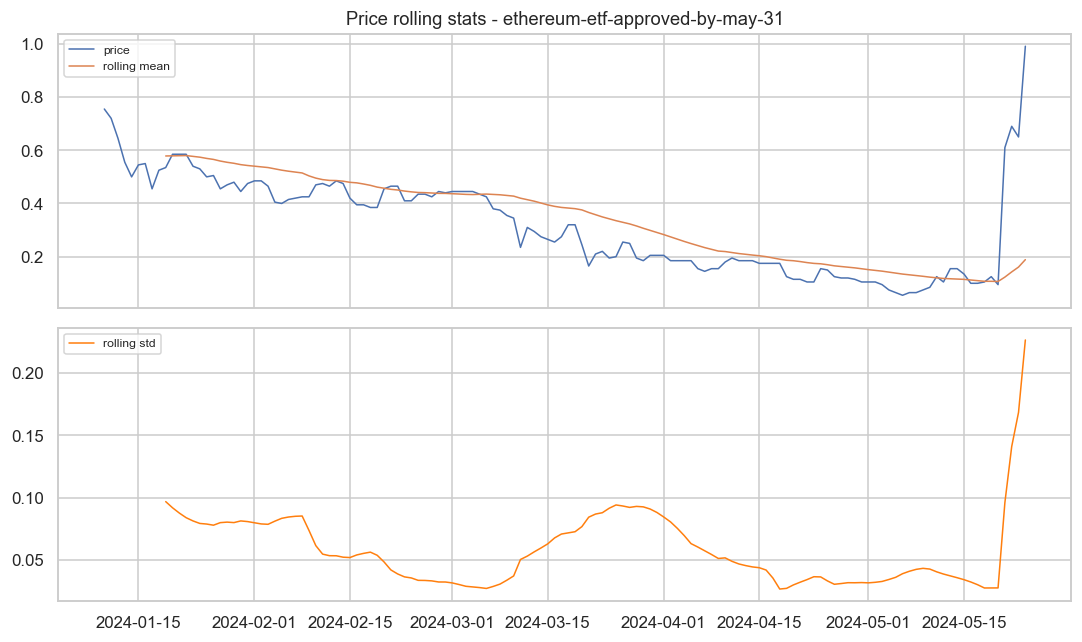

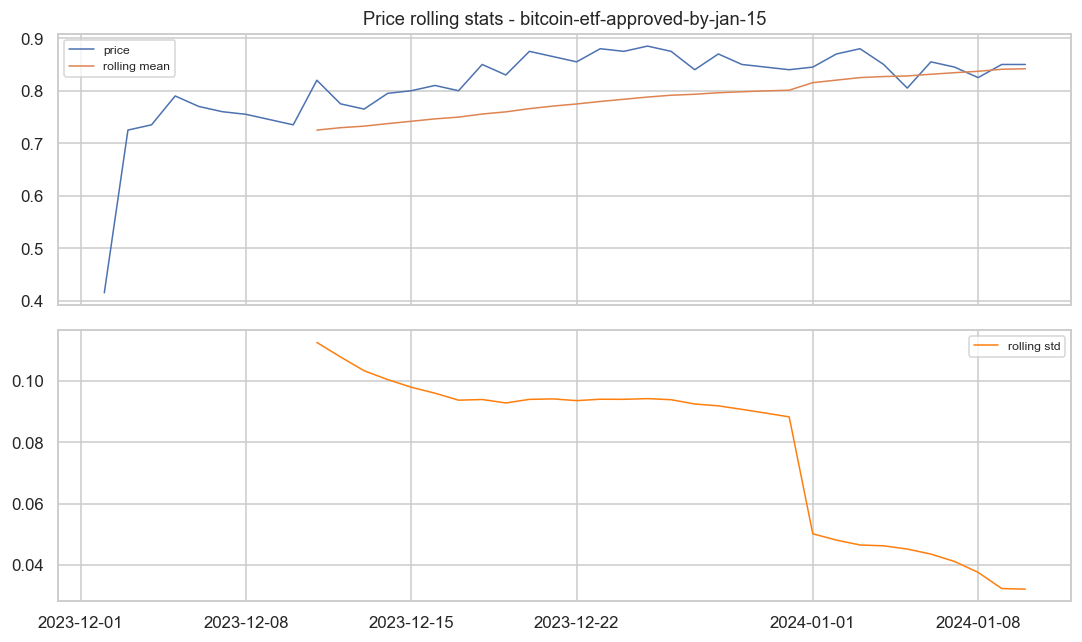

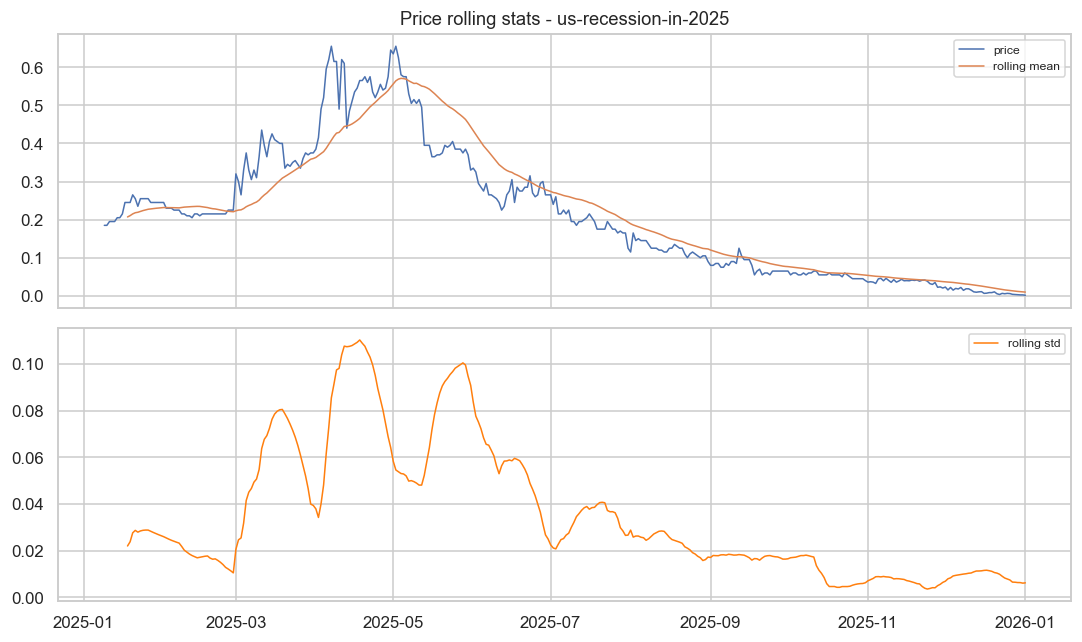

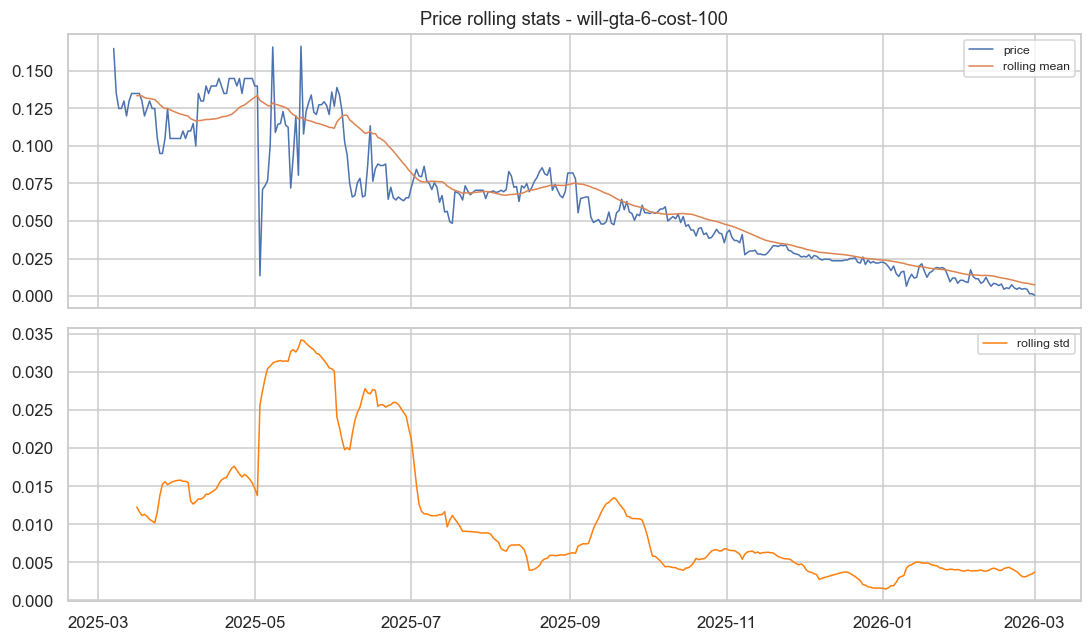

In [14]:
ROLL = 30
sample_slugs = top_slugs[:4]

for slug in sample_slugs:
    g = prices_ret[prices_ret["slug"] == slug].sort_values("date")
    x = g["date"].dt.tz_localize(None)
    roll_mean = g["price"].rolling(ROLL, min_periods=10).mean()
    roll_std = g["price"].rolling(ROLL, min_periods=10).std()

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axes[0].plot(x, g["price"], label="price", linewidth=1.0)
    axes[0].plot(x, roll_mean, label="rolling mean", linewidth=1.0)
    axes[0].set_title(f"Price rolling stats - {slug[:40]}")
    axes[0].legend(fontsize=8)

    axes[1].plot(x, roll_std, label="rolling std", linewidth=1.0, color="tab:orange")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(OUT_DIR / f"rolling_stats_price_{slug[:40]}.png", bbox_inches="tight")
    plt.show()

c:\Users\oscar\repos\predikt\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\oscar\repos\predikt\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


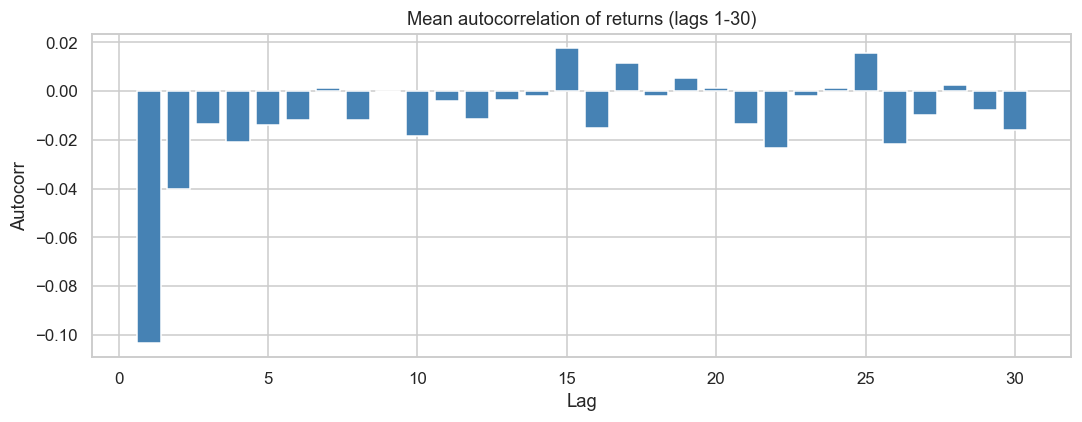

In [15]:
MAX_LAG = 30
acf_rows = []
for slug, g in prices_ret.groupby("slug"):
    s = g["ret_1d"].dropna()
    if len(s) < MAX_LAG + 2:
        continue
    acf_vals = [s.autocorr(lag) for lag in range(1, MAX_LAG + 1)]
    acf_rows.append(acf_vals)

if acf_rows:
    acf_mean = np.nanmean(np.array(acf_rows), axis=0)
    lags = np.arange(1, MAX_LAG + 1)
    plt.figure(figsize=(10, 4))
    plt.bar(lags, acf_mean, color="steelblue")
    plt.title("Mean autocorrelation of returns (lags 1-30)")
    plt.xlabel("Lag")
    plt.ylabel("Autocorr")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "acf_mean.png", bbox_inches="tight")
    plt.show()
else:
    print("Not enough data for autocorrelation summary.")

## Feature and label EDA

We look at label balance and feature correlations in the processed dataset. Labels skew toward 0 (1661 vs 954), per-market pct UP mostly sits around 0.26 to 0.46, and features are strongly collinear (especially moving averages and price) while correlations with the label are weak, implying limited linear signal for next-day direction.

In [16]:
if features_path.exists():
    features = pd.read_csv(features_path, parse_dates=["date"])
else:
    frames = []
    for slug, g in prices_all.groupby("slug"):
        g = g[["date", "price"]].copy()
        g = g.sort_values("date").reset_index(drop=True)
        g = build_market_features(g)
        g = build_labels(g)
        g["slug"] = slug
        frames.append(g)
    features = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print(f"Feature rows: {len(features)}")
features.head()

Feature rows: 2615


,date,slug,ret_1d,ret_3d,ret_7d,ma7,ma14,ma_ratio,vol7,price,label
0,2025-04-03 00:00:00+00:00,bitboy-convicted,0.529259,0.529259,0.196115,0.247857,0.254375,0.974377,0.234573,0.365,0
1,2025-04-04 00:00:00+00:00,bitboy-convicted,0.000000,0.529259,0.358634,0.263571,0.266667,0.988393,0.220172,0.365,1
2,2025-04-05 00:00:00+00:00,bitboy-convicted,0.284252,0.813511,0.642885,0.296429,0.288500,1.027482,0.234870,0.485,1
3,2025-04-06 00:00:00+00:00,bitboy-convicted,0.010256,0.294508,0.823767,0.335714,0.306818,1.094180,0.209793,0.490,1
4,2025-04-07 00:00:00+00:00,bitboy-convicted,0.010152,0.304660,0.833920,0.375714,0.322500,1.165006,0.208877,0.495,1


,label,count
0,0,1661
1,1,954


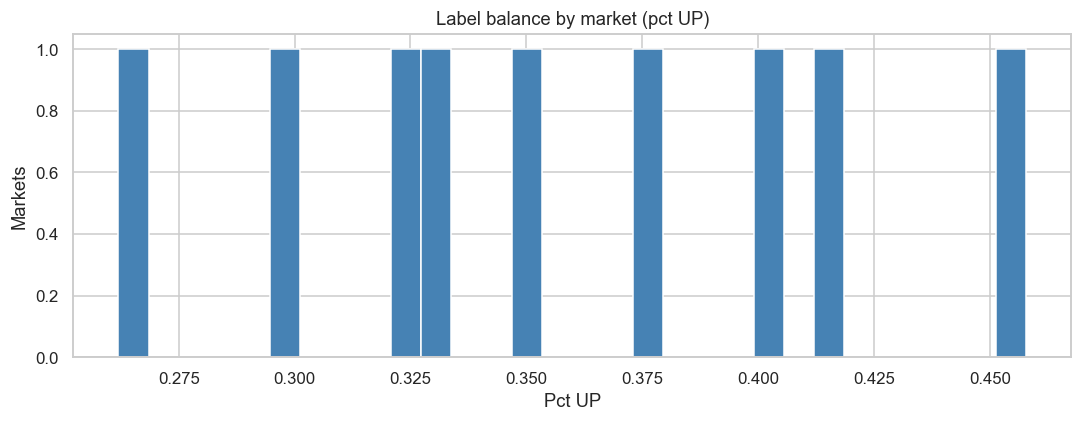

In [17]:
if not features.empty and "label" in features.columns:
    label_counts = features["label"].value_counts(dropna=False).reset_index()
    label_counts.columns = ["label", "count"]
    label_counts.to_csv(OUT_DIR / "label_balance_overall.csv", index=False)
    display(label_counts)

    by_market = features.groupby("slug")["label"].mean().reset_index()
    by_market.columns = ["slug", "pct_up"]
    by_market.to_csv(OUT_DIR / "label_balance_by_market.csv", index=False)

    plt.figure(figsize=(10, 4))
    plt.hist(by_market["pct_up"].dropna(), bins=30, color="steelblue", edgecolor="white")
    plt.title("Label balance by market (pct UP)")
    plt.xlabel("Pct UP")
    plt.ylabel("Markets")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "label_balance_hist.png", bbox_inches="tight")
    plt.show()
else:
    print("No label column found in features.")

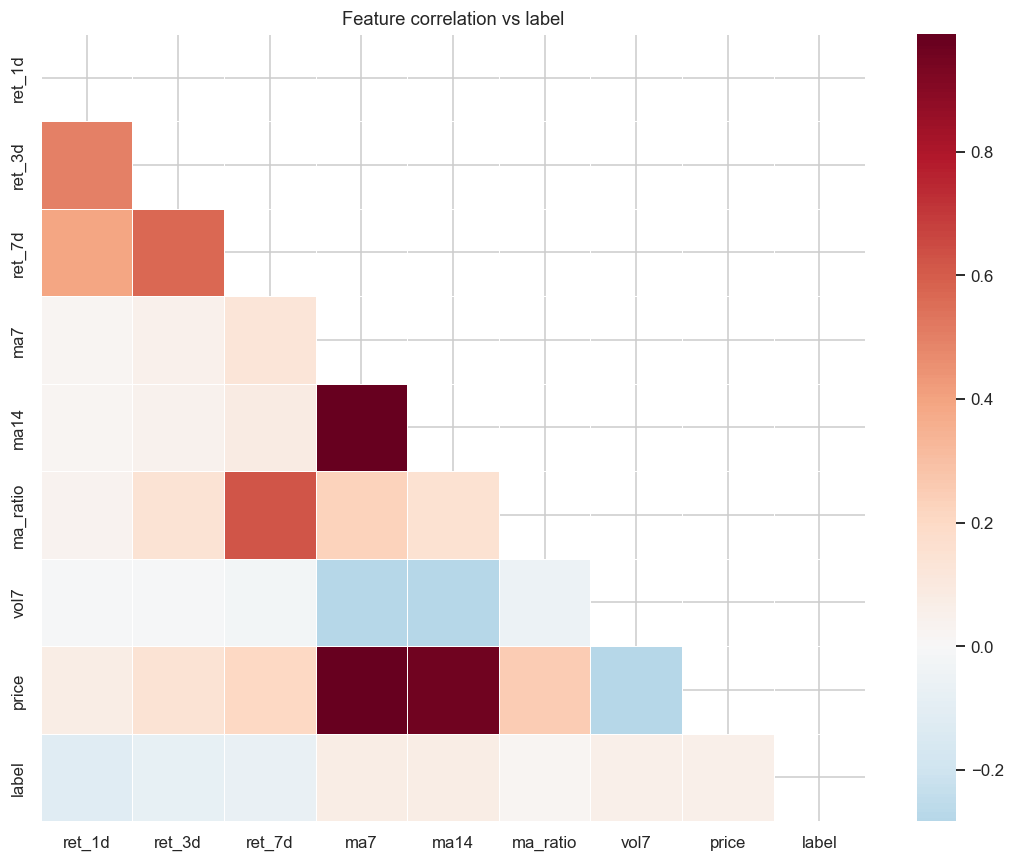

In [18]:
if not features.empty and "label" in features.columns:
    exclude = {"date", "slug", "question", "label"}
    feature_cols = [c for c in features.columns if c not in exclude]
    corr = features[feature_cols + ["label"]].corr()

    plt.figure(figsize=(10, 8))
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, linewidths=0.5)
    plt.title("Feature correlation vs label")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "feature_correlation.png", bbox_inches="tight")
    plt.show()
else:
    print("No feature data for correlation plot.")